<a href="https://colab.research.google.com/github/A-Shihab/AmlNetCell/blob/master/Fake_News_Detection_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

mdasaduzzamanshihab_aust_fake_news_detection_bangla_dataset_path = kagglehub.dataset_download('mdasaduzzamanshihab/aust-fake-news-detection-bangla-dataset')

print('Data source import complete.')


Install Dependency

In [ ]:
!pip install -q unsloth
!pip install -q transformers accelerate bitsandbytes peft trl
!pip install -q timm sentencepiece
!pip install -q torchvision
!pip install -q streamlit pyngrok

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.8/57.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.1/71.1 MB 24.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 103.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 869.6/869.6 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 49.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 86.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 6.8 MB/s eta 0:00:0

Import libraries

In [ ]:
import os
import gc
import torch
import torch.nn as nn
import pandas as pd
import numpy as np

from PIL import Image
from tqdm import tqdm

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

from transformers import AutoTokenizer
from transformers import AutoModel
from transformers import BitsAndBytesConfig

import timm

from peft import LoraConfig
from peft import get_peft_model

from unsloth import FastLanguageModel

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
/usr/local/lib/python3.12/dist-packages/unsloth/__init__.py:144: UserWarning: WARNING: Unsloth should be imported before [transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


Confuigaration

In [ ]:
import torch

# =========================
# DEVICE
# =========================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# TRAINING CONFIG
# =========================

MAX_LENGTH = 128

IMAGE_SIZE = 224

# Stable for Kaggle T4
BATCH_SIZE = 2

# First experiment
EPOCHS = 2

# Stable LR for QLoRA + Fusion
LR = 5e-5

# =========================
# MODEL
# =========================

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

# =========================
# DATASET PATH
# =========================

DATASET_PATH = "/kaggle/input/datasets/mdasaduzzamanshihab/aust-fake-news-detection-bangla-dataset"

TRAIN_CSV = f"{DATASET_PATH}/Train.csv"

VAL_CSV = f"{DATASET_PATH}/Validation.csv"

TEST_CSV = f"{DATASET_PATH}/Test.csv"

TRAIN_IMG = f"{DATASET_PATH}/Train"

VAL_IMG = f"{DATASET_PATH}/Validation"

TEST_IMG = f"{DATASET_PATH}/Test"

# =========================
# RANDOM SEED
# =========================

torch.manual_seed(42)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(42)

# =========================
# GPU INFO
# =========================

print("DEVICE:", DEVICE)

if torch.cuda.is_available():

    print("GPU:", torch.cuda.get_device_name(0))

DEVICE: cuda
GPU: Tesla T4


Loading Dataset

In [ ]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print(train_df.head())
print(train_df.columns)

               image_id                                           headline  \
0  entertainment_real_1           মুক্তি পেতেই ঝড় তুললো ‘জওয়ান’র নতুন গান!   
1  entertainment_real_2               নতুন এক সিনেমায় চুক্তিবদ্ধ হলেন দীঘি   
2  entertainment_real_3  এবার মায়ের সঙ্গে শুটিংয়ে যাচ্ছে পদ্ম, ভিডিও ভা...   
3  entertainment_real_4     পরিচালক থেকে এবার অভিনেতা মোস্তফা সরয়ার ফারুকী   
4  entertainment_real_5  কলকাতার সায়ন্তিকাকে নিয়ে কক্সবাজারে উড়াল দিলেন...   

                                         description       category  \
0  এবার প্রকাশ্যে এলো শাহরুখের ‘জওয়ান’র ছবিটির তৃ...  entertainment   
1  ইতোমধ্যে বেশ কয়েকটি সিনেমা এবং ওয়েবসিরিজে কাজ ...  entertainment   
2  চিত্রনায়িকা পরীমণি এক মুহূর্তও যেন ছেলেকে চোখে...  entertainment   
3  মোস্তফা সরয়ার ফারুকী প্রায় পঁচিশ বছর ধরে নির্ম...  entertainment   
4  আজ থেকেই সমুদ্রতীরবর্তী শহরে জায়েদ খান ও সায়ন্...  entertainment   

  types of fake news  label  
0           non-fake      0  
1           non-fake      0  
2           no

Fixing Bangla Encoding Issue

In [ ]:
def fix_bangla_text(text):
    try:
        return text.encode('latin1').decode('utf-8')
    except:
        return text

train_df['headline'] = train_df['headline'].astype(str).apply(fix_bangla_text)
train_df['description'] = train_df['description'].astype(str).apply(fix_bangla_text)

val_df['headline'] = val_df['headline'].astype(str).apply(fix_bangla_text)
val_df['description'] = val_df['description'].astype(str).apply(fix_bangla_text)

test_df['headline'] = test_df['headline'].astype(str).apply(fix_bangla_text)
test_df['description'] = test_df['description'].astype(str).apply(fix_bangla_text)

Headline missing values

In [ ]:
for df in [train_df, val_df, test_df]:

    df['headline'] = df['headline'].fillna("")
    df['description'] = df['description'].fillna("")
    df['image_id'] = df['image_id'].fillna("")

Load Tokenizer

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

tokenizer.pad_token = tokenizer.eos_token

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Image Transforms

In [ ]:
image_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Custom Dataset

In [ ]:
class FakeNewsDataset(Dataset):

    def __init__(self, df, image_folder, tokenizer):

        self.df = df
        self.image_folder = image_folder
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        headline = str(row['headline'])
        description = str(row['description'])

        text = headline + " " + description

        image_id = row['image_id']

        label = int(row['label'])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=MAX_LENGTH,
            return_tensors='pt'
        )

        image_path_jpg = os.path.join(
            self.image_folder,
            image_id + ".jpg"
        )

        image_path_png = os.path.join(
            self.image_folder,
            image_id + ".png"
        )

        image_exists = False

        if os.path.exists(image_path_jpg):

            image = Image.open(
                image_path_jpg
            ).convert("RGB")

            image_exists = True

        elif os.path.exists(image_path_png):

            image = Image.open(
                image_path_png
            ).convert("RGB")

            image_exists = True

        else:

            image = Image.new(
                "RGB",
                (224,224),
                color=(0,0,0)
            )

        image = image_transform(image)

        modality_mask = torch.tensor([
            1 if headline.strip() != "" else 0,
            1 if description.strip() != "" else 0,
            1 if image_exists else 0
        ], dtype=torch.float)

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'image': image,
            'label': torch.tensor(label, dtype=torch.long),
            'modality_mask': modality_mask
        }

Data Loaders

In [ ]:
train_dataset = FakeNewsDataset(
    train_df,
    TRAIN_IMG,
    tokenizer
)

val_dataset = FakeNewsDataset(
    val_df,
    VAL_IMG,
    tokenizer
)

test_dataset = FakeNewsDataset(
    test_df,
    TEST_IMG,
    tokenizer
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE
)

Loading Qween with unsloth

In [ ]:
model_qwen, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_LENGTH,
    dtype=None,
    load_in_4bit=True,
)

==((====))==  Unsloth 2026.5.7: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.53G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Applying Qlora

In [ ]:
model_qwen = FastLanguageModel.get_peft_model(
    model_qwen,

    r=16,

    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj"
    ],

    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",

    use_gradient_checkpointing=True,
)

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.5.7 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Loading siglip Image encoder

In [ ]:
vision_encoder = timm.create_model(
    'vit_base_patch16_siglip_224',
    pretrained=True,
    num_classes=0
)

vision_encoder = vision_encoder.to(DEVICE)

model.safetensors:   0%|          | 0.00/372M [00:00<?, ?B/s]

Cross attention Fusion module

In [ ]:
class CrossAttentionFusion(nn.Module):

    def __init__(self, dim=768, heads=8):

        super().__init__()

        self.text_to_image = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=heads,
            batch_first=True
        )

        self.image_to_text = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=heads,
            batch_first=True
        )

    def forward(self, text_feat, image_feat):

        text_attended, _ = self.text_to_image(
            text_feat,
            image_feat,
            image_feat
        )

        image_attended, _ = self.image_to_text(
            image_feat,
            text_feat,
            text_feat
        )

        return text_attended, image_attended

Modality Gate

In [ ]:
class ModalityGate(nn.Module):

    def __init__(self, dim=768):

        super().__init__()

        self.gate = nn.Sequential(

            nn.Linear(
                dim,
                dim,
                dtype=torch.float16
            ),

            nn.ReLU(),

            nn.Linear(
                dim,
                1,
                dtype=torch.float16
            ),

            nn.Sigmoid()
        )

    def forward(self, x):

        return self.gate(x)

Complete multimodel model

In [ ]:
class FakeNewsModel(nn.Module):

    def __init__(self, qwen_model, vision_model):

        super().__init__()

        # =========================
        # BACKBONES
        # =========================

        self.qwen = qwen_model

        self.vision = vision_model

        # =========================
        # PROJECTION LAYERS
        # =========================

        # Qwen hidden size = 1536
        self.text_projection = nn.Linear(
            1536,
            768
        )

        # SigLIP feature size = 768
        self.image_projection = nn.Linear(
            768,
            768
        )

        # =========================
        # CROSS ATTENTION
        # =========================

        self.cross_attention = nn.MultiheadAttention(

            embed_dim=768,

            num_heads=8,

            batch_first=True

        )

        # =========================
        # MODALITY GATES
        # =========================

        self.text_gate = nn.Sequential(

            nn.Linear(768, 768),

            nn.ReLU(),

            nn.Linear(768, 1),

            nn.Sigmoid()

        )

        self.image_gate = nn.Sequential(

            nn.Linear(768, 768),

            nn.ReLU(),

            nn.Linear(768, 1),

            nn.Sigmoid()

        )

        # =========================
        # CLASSIFIER
        # =========================

        self.classifier = nn.Sequential(

            nn.Linear(1536, 512),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(512, 2)

        )

    def forward(

        self,

        input_ids,

        attention_mask,

        image,

        modality_mask

    ):

        # =========================
        # TEXT FEATURES
        # =========================

        text_output = self.qwen.model(

            input_ids=input_ids,

            attention_mask=attention_mask,

            output_hidden_states=True,

            return_dict=True

        )

        # Last hidden state
        text_feat = text_output.hidden_states[-1]

        # IMPORTANT FIX
        text_feat = text_feat.float()

        # Projection
        text_feat = self.text_projection(text_feat)

        # =========================
        # IMAGE FEATURES
        # =========================

        image_feat = self.vision.forward_features(image)

        # Some timm models return:
        # [B, Tokens, Dim]
        if len(image_feat.shape) == 3:

            image_feat = image_feat.mean(dim=1)

        # IMPORTANT FIX
        image_feat = image_feat.float()

        # Projection
        image_feat = self.image_projection(image_feat)

        # Add sequence dimension
        image_feat = image_feat.unsqueeze(1)

        # =========================
        # CROSS ATTENTION
        # =========================

        attended_text, _ = self.cross_attention(

            query=text_feat,

            key=image_feat,

            value=image_feat

        )

        # =========================
        # GLOBAL POOLING
        # =========================

        text_pool = attended_text.mean(dim=1)

        image_pool = image_feat.mean(dim=1)

        # =========================
        # MODALITY GATING
        # =========================

        text_weight = self.text_gate(text_pool)

        image_weight = self.image_gate(image_pool)

        text_pool = text_pool * text_weight

        image_pool = image_pool * image_weight

        # =========================
        # MISSING MODALITY MASKING
        # =========================

        text_mask = modality_mask[:,0].unsqueeze(1)

        image_mask = modality_mask[:,2].unsqueeze(1)

        text_pool = text_pool * text_mask

        image_pool = image_pool * image_mask

        # =========================
        # FINAL FUSION
        # =========================

        fused = torch.cat([

            text_pool,

            image_pool

        ], dim=1)

        # =========================
        # CLASSIFICATION
        # =========================

        logits = self.classifier(fused)

        return logits

Initializing Model

In [ ]:
model = FakeNewsModel(
    model_qwen,
    vision_encoder
)

model = model.to(DEVICE)

print("Model Loaded Successfully")

# =========================
# ENABLE TRAIN MODE
# =========================

model.train()

# =========================
# CLEAR GPU CACHE
# =========================

torch.cuda.empty_cache()

gc.collect()

# =========================
# PRINT GPU INFO
# =========================

if torch.cuda.is_available():

    print("GPU:", torch.cuda.get_device_name(0))

    print(
        "GPU Memory Allocated:",
        round(
            torch.cuda.memory_allocated(0)/1024**3,
            2
        ),
        "GB"
    )

    print(
        "GPU Memory Reserved:",
        round(
            torch.cuda.memory_reserved(0)/1024**3,
            2
        ),
        "GB"
    )

Model Loaded Successfully
GPU: Tesla T4
GPU Memory Allocated: 2.31 GB
GPU Memory Reserved: 2.75 GB


Loss Fucntion and optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=5e-5,

    weight_decay=1e-4

)

print("Optimizer Loaded")

Optimizer Loaded


Trainning Loop

In [ ]:
from tqdm import tqdm

train_losses = []

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for batch in tqdm(train_loader):

        # =========================
        # LOAD BATCH
        # =========================

        input_ids = batch['input_ids'].to(DEVICE)

        attention_mask = batch['attention_mask'].to(DEVICE)

        # IMPORTANT FIX
        # REMOVE .half()
        image = batch['image'].to(DEVICE)

        labels = batch['label'].to(DEVICE)

        modality_mask = batch['modality_mask'].to(DEVICE)

        # =========================
        # ZERO GRAD
        # =========================

        optimizer.zero_grad()

        # =========================
        # FORWARD PASS
        # =========================

        outputs = model(

            input_ids,

            attention_mask,

            image,

            modality_mask

        )

        # =========================
        # LOSS
        # =========================

        loss = criterion(

            outputs,

            labels

        )

        # =========================
        # BACKPROP
        # =========================

        loss.backward()

        # =========================
        # GRADIENT CLIPPING
        # =========================

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        # =========================
        # OPTIMIZER STEP
        # =========================

        optimizer.step()

        total_loss += loss.item()

    # =========================
    # EPOCH LOSS
    # =========================

    avg_loss = total_loss / len(train_loader)

    train_losses.append(avg_loss)

    print(f"\nEpoch {epoch+1}")

    print(f"Training Loss: {avg_loss:.4f}")

100%|██████████| 1920/1920 [25:06<00:00,  1.27it/s]



Epoch 1
Training Loss: 0.6592


100%|██████████| 1920/1920 [24:04<00:00,  1.33it/s]


Epoch 2
Training Loss: 0.6621


Validation Loop

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

model.eval()

val_predictions = []

val_true_labels = []

val_loss = 0

with torch.no_grad():

    for batch in tqdm(val_loader):

        # =========================
        # LOAD BATCH
        # =========================

        input_ids = batch['input_ids'].to(DEVICE)

        attention_mask = batch['attention_mask'].to(DEVICE)

        image = batch['image'].to(DEVICE)

        labels = batch['label'].to(DEVICE)

        modality_mask = batch['modality_mask'].to(DEVICE)

        # =========================
        # FORWARD PASS
        # =========================

        outputs = model(

            input_ids,

            attention_mask,

            image,

            modality_mask

        )

        # =========================
        # LOSS
        # =========================

        loss = criterion(

            outputs,

            labels

        )

        val_loss += loss.item()

        # =========================
        # PREDICTIONS
        # =========================

        preds = torch.argmax(

            outputs,

            dim=1

        )

        val_predictions.extend(

            preds.cpu().numpy()

        )

        val_true_labels.extend(

            labels.cpu().numpy()

        )

# =========================
# METRICS
# =========================

val_accuracy = accuracy_score(

    val_true_labels,

    val_predictions

)

val_f1 = f1_score(

    val_true_labels,

    val_predictions

)

avg_val_loss = val_loss / len(val_loader)

print("\n==============================")

print("VALIDATION RESULTS")

print("==============================")

print(f"Validation Loss     : {avg_val_loss:.4f}")

print(f"Validation Accuracy : {val_accuracy:.4f}")

print(f"Validation F1 Score : {val_f1:.4f}")

print("==============================")

100%|██████████| 240/240 [01:09<00:00,  3.44it/s]


VALIDATION RESULTS
Validation Loss     : 0.6464
Validation Accuracy : 0.6583
Validation F1 Score : 0.7433


Confsuion Metrix

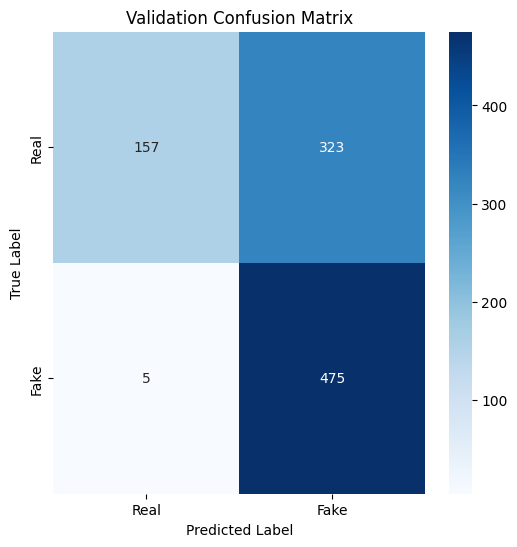

In [ ]:
from sklearn.metrics import confusion_matrix

import seaborn as sns

import matplotlib.pyplot as plt

# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(

    val_true_labels,

    val_predictions

)

# =========================
# PLOT
# =========================

plt.figure(figsize=(6,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=['Real','Fake'],

    yticklabels=['Real','Fake']

)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("Validation Confusion Matrix")

plt.show()

Roc Curve Plus Auc Score

  0%|          | 0/240 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
100%|██████████| 240/240 [01:02<00:00,  3.82it/s]


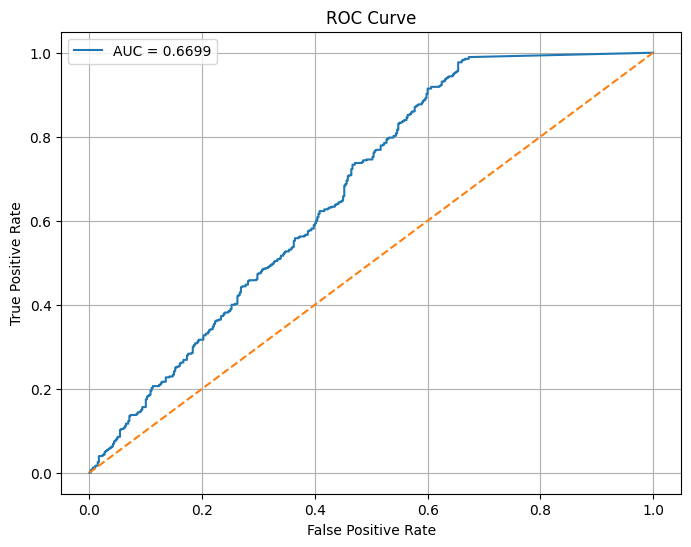


ROC-AUC Score: 0.6698632812499999


In [ ]:
from sklearn.metrics import roc_curve

from sklearn.metrics import auc

# =========================
# EVALUATION MODE
# =========================

model.eval()

all_probs = []

all_labels = []

# =========================
# NO GRAD
# =========================

with torch.no_grad():

    for batch in tqdm(val_loader):

        input_ids = batch['input_ids'].to(DEVICE)

        attention_mask = batch['attention_mask'].to(DEVICE)

        image = batch['image'].to(DEVICE)

        labels = batch['label'].to(DEVICE)

        modality_mask = batch['modality_mask'].to(DEVICE)

        # =========================
        # FORWARD PASS
        # =========================

        outputs = model(

            input_ids,

            attention_mask,

            image,

            modality_mask

        )

        # =========================
        # SOFTMAX PROBABILITIES
        # =========================

        probs = torch.softmax(

            outputs,

            dim=1

        )[:,1]

        all_probs.extend(

            probs.cpu().numpy()

        )

        all_labels.extend(

            labels.cpu().numpy()

        )

# =========================
# ROC CURVE
# =========================

fpr, tpr, thresholds = roc_curve(

    all_labels,

    all_probs

)

# =========================
# AUC SCORE
# =========================

roc_auc = auc(

    fpr,

    tpr

)

# =========================
# PLOT
# =========================

plt.figure(figsize=(8,6))

plt.plot(

    fpr,

    tpr,

    label=f"AUC = {roc_auc:.4f}"

)

plt.plot(

    [0,1],

    [0,1],

    linestyle='--'

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

# =========================
# PRINT SCORE
# =========================

print("\nROC-AUC Score:", roc_auc)